# 03. Machine Learning (multi-horizonte h = 1, 2, 3)

Features de lags, médias e desvios móveis e calendário são usadas para treinar modelos de Machine Learning, seguindo a estratégia direta de multi-horizonte: um modelo especialista para cada horizonte (`target_h1`, `target_h2`, `target_h3`), cada um prevendo `Close` diretamente a partir do que se sabia até o dia da origem, sem encadear previsões, diferente da estratégia recursiva, que usaria a própria previsão de h=1 como insumo para prever h=2.

A estratégia direta evita o acúmulo de erro de recursão e é mais simples de validar corretamente no tempo.

In [1]:
import sys
sys.path.append("../src")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import case_utils as cu

RANDOM_STATE = 42
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#e5e5e5", "grid.linewidth": 0.8, "font.size": 11,
})


In [2]:
train, test = cu.load_processed("../data/processed")
full = cu.make_full_series(train, test)
full_dates = full["Date"].values

origins = cu.walkforward_origins(len(train), len(test), max_h=max(cu.HORIZONS))
FEATURE_COLS = cu.feature_columns()
print(f"{len(FEATURE_COLS)} features:", FEATURE_COLS)


19 features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_10', 'lag_20', 'roll_mean_5', 'roll_std_5', 'roll_mean_10', 'roll_std_10', 'roll_mean_20', 'roll_std_20', 'return_1', 'return_5', 'dow', 'day', 'month', 'volume_lag1']


## Engenharia de features e alvos diretos por horizonte

`build_features` usa somente `Close.shift(1)` para qualquer estatística móvel, ou seja, a feature da linha `t` nunca enxerga o `Close` do próprio dia `t`. `build_direct_targets` cria `target_h1/h2/h3` como o `Close` de `t+1`, `t+2`, `t+3`, alinhado com as features de `t`.

In [3]:
feat_train = cu.build_features(train)
feat_train = cu.build_direct_targets(feat_train, horizons=cu.HORIZONS)

target_cols = [f"target_h{h}" for h in cu.HORIZONS]
feat_train_clean = feat_train.dropna(subset=FEATURE_COLS + target_cols).reset_index(drop=True)
print(f"Linhas antes da limpeza: {len(feat_train)} | depois (sem NaN de lag/target): {len(feat_train_clean)}")
feat_train_clean[["Date"] + FEATURE_COLS[:4] + target_cols].head(3)


Linhas antes da limpeza: 1345 | depois (sem NaN de lag/target): 1322


,Date,lag_1,lag_2,lag_3,lag_4,target_h1,target_h2,target_h3
0,2013-01-31,18.200001,19.110001,19.370001,19.610001,18.459999,18.00,18.08
1,2013-02-01,18.080000,18.200001,19.110001,19.370001,18.000000,18.08,17.60
2,2013-02-04,18.459999,18.080000,18.200001,19.110001,18.080000,17.60,17.50


## Seleção do algoritmo por horizonte (validação temporal interna)

Para cada horizonte, os últimos 40 dias úteis do treino são separados como validação interna, sem tocar no teste real nesta etapa, e três algoritmos são comparados: Ridge (linear regularizado), Random Forest e Gradient Boosting.

In [4]:
N_VAL = 40
candidates = {
    "ridge": Ridge(alpha=5.0),
    "random_forest": RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=3, random_state=RANDOM_STATE),
    "gradient_boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, random_state=RANDOM_STATE),
}

inner_train = feat_train_clean.iloc[:-N_VAL]
inner_val = feat_train_clean.iloc[-N_VAL:]

best_algo_per_h = {}
val_scores = []

for h in cu.HORIZONS:
    ycol = f"target_h{h}"
    scores_h = {}
    for name, model in candidates.items():
        model.fit(inner_train[FEATURE_COLS], inner_train[ycol])
        pred = model.predict(inner_val[FEATURE_COLS])
        m = cu.regression_metrics(inner_val[ycol], pred)
        scores_h[name] = m
        val_scores.append({"horizon": h, "algoritmo": name, **m})
    best_algo_per_h[h] = min(scores_h, key=lambda k: scores_h[k]["RMSE"])

val_scores_df = pd.DataFrame(val_scores)
print("Melhor algoritmo por horizonte (validação interna):", best_algo_per_h)
val_scores_df.pivot(index="algoritmo", columns="horizon", values="RMSE").round(3)


Melhor algoritmo por horizonte (validação interna): {1: 'ridge', 2: 'ridge', 3: 'ridge'}


horizon,1,2,3
algoritmo,,,
gradient_boosting,1.870,2.221,2.482
random_forest,1.715,2.112,2.502
ridge,0.949,1.383,1.737


## Retreino final e geração das previsões walk-forward

Com o algoritmo escolhido para cada horizonte, o modelo é retreinado usando todo o treino, incluindo a janela de validação interna, e então as previsões são geradas nas mesmas 17 origens walk-forward dos outros notebooks. Como a estratégia é direta e não recursiva, cada previsão usa apenas features calculadas a partir do histórico real conhecido até a origem, inclusive os dias de teste já revelados nas origens mais avançadas.

In [5]:
final_models = {}
for h in cu.HORIZONS:
    ycol = f"target_h{h}"
    algo_name = best_algo_per_h[h]
    model = candidates[algo_name].__class__(**candidates[algo_name].get_params())
    model.fit(feat_train_clean[FEATURE_COLS], feat_train_clean[ycol])
    final_models[h] = (algo_name, model)
    print(f"h={h}: modelo final = {algo_name}")


h=1: modelo final = ridge
h=2: modelo final = ridge
h=3: modelo final = ridge


In [6]:
rows_ml = []

for origin in origins:
    origin_date = full_dates[origin]
    history_raw = full.iloc[: origin + 1][["Date", "Close", "Volume"]]
    history_feat = cu.build_features(history_raw)
    x_row = history_feat.iloc[[-1]][FEATURE_COLS]

    for h in cu.HORIZONS:
        algo_name, model = final_models[h]
        pred = model.predict(x_row)[0]
        cu.append_predictions(rows_ml, origin_date, full_dates, full["Close"].values, origin, h, f"ml_{algo_name}", pred)

results_ml = pd.DataFrame(rows_ml)
results_ml.to_csv("../results/predictions_ml.csv", index=False)

metrics_ml = cu.summarize_by_horizon(results_ml)
metrics_ml.to_csv("../results/metrics_ml.csv", index=False)
metrics_ml.pivot(index="model", columns="horizon", values="MAPE").round(2)


horizon,1,2,3
model,,,
ml_ridge,6.43,5.6,7.71


## Interpretação do modelo (h = 1)

Como pede a boa prática de ML, o modelo é analisado por dentro antes de confiar nele: quais variáveis pesam mais na previsão de amanhã (h=1)?

Algoritmo escolhido para h=1: ridge


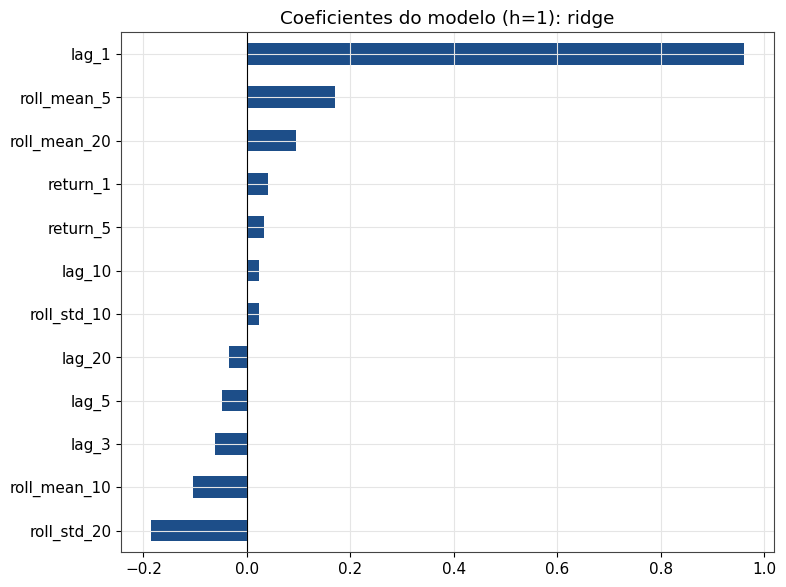

lag_1           0.960849
roll_std_20    -0.185136
roll_mean_5     0.169602
roll_mean_10   -0.103265
roll_mean_20    0.094195
lag_3          -0.061140
lag_5          -0.047715
return_1        0.040466
lag_20         -0.034268
return_5        0.033839
dtype: float64

In [7]:
algo_h1, model_h1 = final_models[1]
print("Algoritmo escolhido para h=1:", algo_h1)

if hasattr(model_h1, "coef_"):
    imp = pd.Series(model_h1.coef_, index=FEATURE_COLS).sort_values(key=np.abs, ascending=False)
    titulo = f"Coeficientes do modelo (h=1): {algo_h1}"
elif hasattr(model_h1, "feature_importances_"):
    imp = pd.Series(model_h1.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    titulo = f"Importância das variáveis (h=1): {algo_h1}"

fig, ax = plt.subplots(figsize=(8, 6))
imp.head(12).sort_values().plot(kind="barh", ax=ax, color=cu.PALETTE["ml_ridge"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(titulo)
fig.tight_layout()
plt.show()

imp.head(10)


## Erro (MAPE) por horizonte, Machine Learning

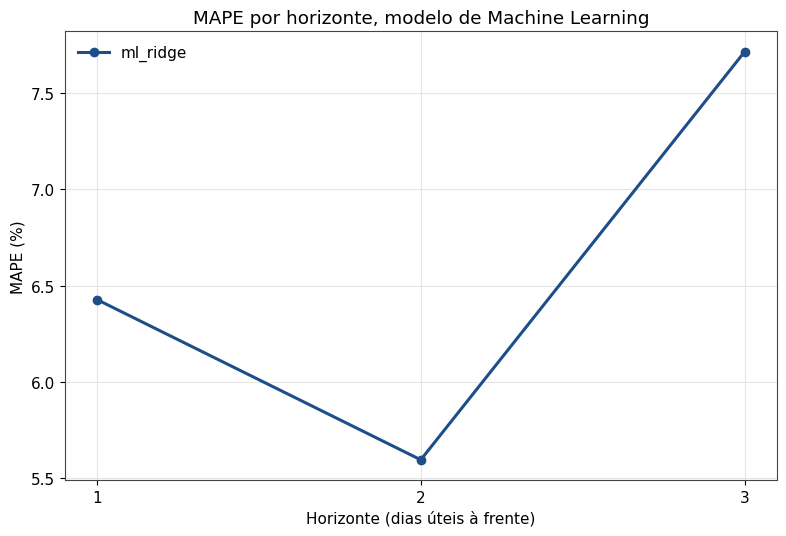

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for model, g in metrics_ml.groupby("model"):
    g = g.sort_values("horizon")
    ax.plot(g["horizon"], g["MAPE"], marker="o", linewidth=2.2, color=cu.PALETTE.get(model, "#D9782D"), label=model)
ax.set_xticks(cu.HORIZONS)
ax.set_xlabel("Horizonte (dias úteis à frente)")
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE por horizonte, modelo de Machine Learning")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


O notebook `04_comparacao_final` junta esses resultados com os do `02_baseline_modelos_classicos` para responder à pergunta central do case: a complexidade extra do Machine Learning compensa, horizonte a horizonte?